
FIT 1

###
A =  8693 ± 109.6
B = 101.1 ± 0.147
###
┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 80.38                      │             Nfcn = 1820              │
│ EDM = 9.61e-05 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │     Covariance FORCED pos. def.      │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬

/tmp/ipykernel_40401/2289538586.py:17: RuntimeWarning: invalid value encountered in power
  return (A / (x-B)**D) + C


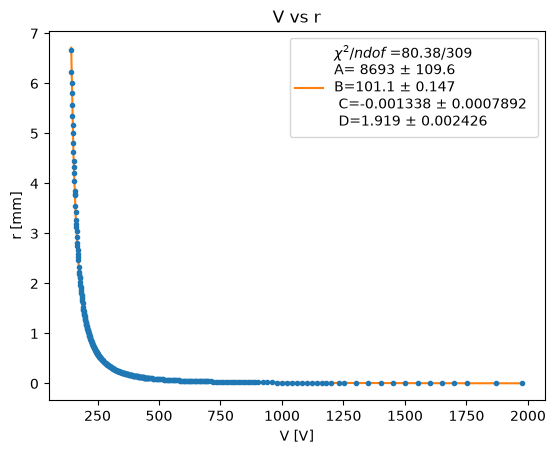


FIT 2

###
Constant = 216.3 ± 16.84
Mean = -0.04982 ± 0.03143
Sigma = 0.5428 ± 0.02612
###
┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 20.33                      │              Nfcn = 431              │
│ EDM = 4.91e-07 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴────────────────────────────────────

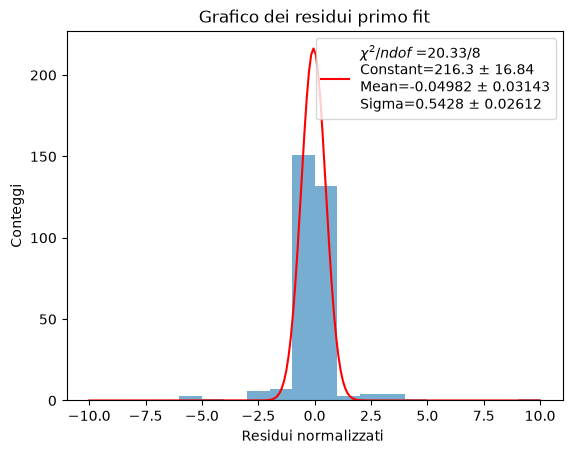


FIT 3

###
q = -0.0002941 ± 0.000846
m = 6.321e-07 ± 1.435e-06
###
┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 368.1                      │              Nfcn = 103              │
│ EDM = 0.00011 (Goal: 0.0002)     │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬────────

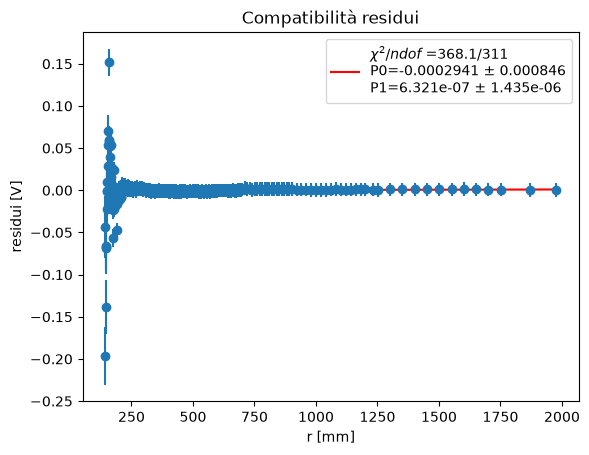

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from iminuit import Minuit

# Leggiamo solo la colonna 0 (x) e la colonna 1 (y) ignorando le altre
dati = np.loadtxt("datpy.txt", encoding="utf-16", skiprows=1, usecols=(0, 1))

x = dati[:,0]
y = dati[:,1]

# Creiamo le colonne degli errori costanti direttamente in Python!
ex = np.full(len(x), 0.115470054)
ey = np.full(len(x), 0.008164966)


def fitfunc(x, A , B, C, D):
    return (A / (x-B)**D) + C

def fitfuncprime(x, A, B, C, D):
    dx = 1e-6
    return (fitfunc(x+dx/2, A, B, C, D)-fitfunc(x-dx/2, A, B, C, D))/dx

def chi2_fitfunc(A, B, C, D ):
    sigma = np.sqrt(ey**2 + (ex * fitfuncprime(x, A, B, C, D)**2))
    return np.sum(((y - fitfunc(x, A, B, C, D)) / sigma)**2)

print("")
print("FIT 1")
print("")

m = Minuit(chi2_fitfunc, A=1.0, B=0, C=0, D=2)
m.migrad()
m.hesse()
m.minos()

A_fit = m.values["A"]
B_fit = m.values["B"]
C_fit = m.values["C"]
D_fit = m.values["D"]

A_err = m.errors["A"]
B_err = m.errors["B"]
C_err = m.errors["C"]
D_err = m.errors["D"]

print("###")
print(f"A = {A_fit:5.4g} ± {A_err:5.4g}")
print(f"B = {B_fit:5.4g} ± {B_err:5.4g}")
print("###")
print(m)
print("###")

x_fit = np.linspace(min(x), max(x), 200)
y_fit = fitfunc(x_fit, A_fit, B_fit, C_fit, D_fit)

plt.errorbar(x, y, xerr=ex, yerr=ey, fmt='.')
plt.plot(x_fit, y_fit, label=f"$\\chi^2/ndof$ ={chi2_fitfunc(A_fit, B_fit, C_fit, D_fit):5.4g}/{len(x)-4}\nA={A_fit:5.4g} $\\pm$ {A_err:5.4g}\nB={B_fit:5.4g} $\\pm$ {B_err:5.4g} \n C={C_fit:5.4g} $\\pm$ {C_err:5.4g} \n D={D_fit:5.4g} $\\pm$ {D_err:5.4g}")

plt.title(f'V vs r')
plt.xlabel('V [V]')
plt.ylabel('r [mm]')
plt.legend()
plt.savefig("FIT1_conD.pdf")
plt.show()

# ---- residui ----

y_res = y - fitfunc(x, A_fit, B_fit, C_fit, D_fit)
ey_eff = np.sqrt(ey**2 + (ex * fitfuncprime(x, A_fit, B_fit, C_fit, D_fit))**2)

print("")
print("FIT 2")
print("")

plt.figure()
counts, bins, _ = plt.hist(y_res / ey_eff, range=(-10,10), bins=20, alpha=0.6)

def gauss(x, par0, par1, par2):
    return par0 * np.exp(-0.5 * np.power((x - par1) / par2, 2.0))

def chi2_gauss(par0, par1, par2):
    mask = counts>0
    return np.sum(((counts[mask] - gauss((bins[:-1] + bins[1:])[mask]/2, par0, par1, par2)) / np.sqrt(counts[mask]))**2)

m = Minuit(chi2_gauss, par0=1.0, par1=0.0, par2=1.0)
m.migrad()
m.hesse()
m.minos()

Constant_fit = m.values["par0"]
Mean_fit = m.values["par1"]
Sigma_fit = m.values["par2"]

Constant_err = m.errors["par0"]
Mean_err = m.errors["par1"]
Sigma_err = m.errors["par2"]

print("###")
print(f"Constant = {Constant_fit:5.4g} ± {Constant_err:5.4g}")
print(f"Mean = {Mean_fit:5.4g} ± {Mean_err:5.4g}")
print(f"Sigma = {Sigma_fit:5.4g} ± {Sigma_err:5.4g}")
print("###")
print(m)
print("###")

x_fit = np.linspace(-10, 10, 200)
y_fit = gauss(x_fit, Constant_fit, Mean_fit, Sigma_fit)

plt.plot(x_fit, y_fit, 'r-', label=f"$\\chi^2/ndof$ ={chi2_gauss(Constant_fit, Mean_fit, Sigma_fit):5.4g}/{np.count_nonzero(counts)-3}\nConstant={Constant_fit:5.4g} $\\pm$ {Constant_err:5.4g}\nMean={Mean_fit:5.4g} $\\pm$ {Mean_err:5.4g}\nSigma={Sigma_fit:5.4g} $\\pm$ {Sigma_err:5.4g}")

plt.title(f"Grafico dei residui primo fit")
plt.xlabel("Residui normalizzati ")
plt.ylabel("Conteggi")
plt.legend()
plt.savefig("Grafico_residui_1_FIT_conD.pdf")
plt.show()


print("")
print("FIT 3")
print("")

plt.figure()
plt.errorbar(x, y_res, yerr=ey_eff, fmt='o')

def retta(x, par0, par1):
    return par0 + par1 * x

def chi2_retta(par0, par1):
    sigma = ey_eff
    return np.sum(((y_res - retta(x, par0, par1)) / ey_eff)**2)

m = Minuit(chi2_retta, par0=0.0, par1=0.0)
m.migrad()
m.hesse()
m.minos()

q_fit = m.values["par0"]
m_fit = m.values["par1"]

q_err = m.errors["par0"]
m_err = m.errors["par1"]

print("###")
print(f"q = {q_fit:5.4g} ± {q_err:5.4g}")
print(f"m = {m_fit:5.4g} ± {m_err:5.4g}")
print("###")
print(m)
print("###")

x_fit = np.linspace(min(x), max(x), 200)
y_fit = retta(x_fit, q_fit, m_fit)

plt.plot(x_fit, y_fit, 'r-', label=f"$\\chi^2/ndof$ ={chi2_retta(q_fit, m_fit):5.4g}/{len(x)-2}\nP0={q_fit:5.4g} $\\pm$ {q_err:5.4g}\nP1={m_fit:5.4g} $\\pm$ {m_err:5.4g}")

#plt.ylim(-2.0, +2.0)

plt.title(f"Compatibilità residui")
plt.xlabel("r [mm]")
plt.ylabel("residui [V]")
plt.legend()
plt.savefig("Grafico_compatibilita_residui_conD.pdf")
plt.show()

###

plt.show()